# Fresnel Propagation with `abcdLux`

This tutorial is designed as an introduction to some of the new [`abcdLux`](https://github.com/LouisDesdoigts/abcdLux) backend propagators for dLux. This library is still in development but adds a huge amount of flexibility and functionality to dLux's propagation capabilities. It provides full paraxial Fresnel propagation capabilities through the Angular Spectrum Method (ASM) and the Linear Canonical Transform (LCT), allows optical systems to be described and modelled through a series of abcd matrices, provides explicit propagation kernel caching, and provides a more general set of 2-sided Matrix Fourier Transform (MFT) propagators. dLux provided a number of high-level propagator wrappers for these functionalities, however this module is still considered in-development and is subject to change. 

This tutorial will show how we can use this new functionality to do high-dimensional phase retrieval on a JWST-like system using intentionally defocused PSFs.

In [1]:
# Basic imports
import jax.numpy as np
import jax.random as jr

# Optimisation imports
import zodiax as zdx
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import CenteredNorm

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 120

# Nan friendly colormapping
inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

---

## Constructing the Optical System

We will start here by generating a JWST-like optical system using an MFT propagator to get to the focal plane with an optical defocus. We will also use a Fourier basis layer to generate some high-dimensional aberrations within the system to recover.

In [2]:
# Define our properties
wf_npix = 256  # Number of pixels in the wavefront
diameter = 6.6  # Aperture diameter
focal_length = 130  # Effective focal length of the internal optics
defocus = 30e-3  # Defocus of the focal plane

# Propagate to the science plane using an MFT Fresnel propagator
psf_npix = 128  # Number of pixels in the PSF
psf_pixel_scale = 10e-6  # 10 microns

# Propagate to focus using an MFT Fresnel propagator
pupil_spec = dl.GridSpec(n=wf_npix, diam=diameter, unit="m")
psf_spec = dl.GridSpec(n=psf_npix, d=psf_pixel_scale, unit="m")
to_focal = dl.ABCDPropagator(
    [
        ("ThinLens", dl.ABCDFraunhofer(focal_length)),  # Pupil -> Focal
        ("FreeSpace", dl.ABCDFreeSpace(-defocus)),  # Focal -> Defocused Detector
    ],
    psf_spec,
)

# Generate other layers
aper = dlu.jwst_like(npixels=wf_npix, oversample=5)
pupil = dl.Optic(
    transmission=aper, opd=dl.FourierBasis(wf_npix, n_modes=64), normalise=True
)

# Define the optical layers and construct the system
layers = [("pupil", pupil), ("to_focal", to_focal)]
optics = dl.OpticalSystem(layers, pupil_spec)

# Examine the optics object
print(optics)

OpticalSystem(
  layers={
    'pupil':
    Optic(
      opd=FourierBasis(
        coeffs=f32[64,64], shape=(64, 64), kernels=(f32[256,64], f32[256,64])
      ),
      phase=None,
      transmission=f32[256,256],
      normalise=True
    ),
    'to_focal':
    ABCDPropagator(
      grid=GridSpec(n=(128, 128), d=f32[2], c=None, unit='m'),
      ABCDs={
        'ThinLens': ABCDFraunhofer(focal_length=f32[]),
        'FreeSpace': ABCDFreeSpace(distance=f32[])
      },
      method='lct'
    )
  },
  grid=GridSpec(n=(256, 256), d=f32[2], c=None, unit='m')
)


Great now lets put some random phase error in and see how our +- defocused PSFs look.

In [3]:
# Define some random coeffs for the Fourier basis
coeffs = 2.0e-9 * jr.normal(jr.key(0), optics.pupil.opd.coeffs.shape)
optics = optics.set("pupil.opd.coeffs", coeffs)

# Model the positive and negative defocused PSFs
psf_pos = optics.propagate(1e-6)
psf_neg = optics.multiply("to_focal.ABCDs.FreeSpace.distance", -1).propagate(1e-6)

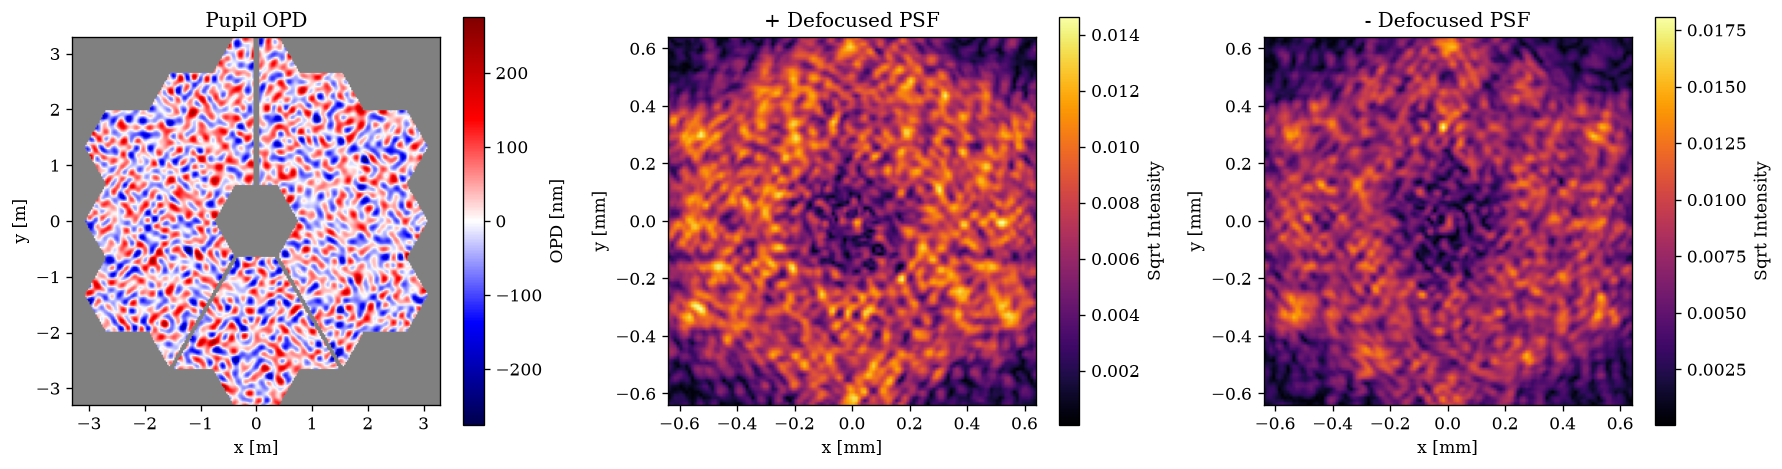

In [4]:
## COLLAPSE: Plotting code
pupil = 1e9 * optics.pupil.opd.evaluate().at[aper <= 0].set(np.nan)
ap_ext = dlu.imshow_extent(optics.grid.fov[0])
psf_ext = dlu.imshow_extent(1e3 * psf_spec.fov[0])

plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
plt.imshow(pupil, seismic, norm=CenteredNorm(), extent=ap_ext)
plt.colorbar(label="OPD [nm]")
ax.set(xlabel="x [m]", ylabel="y [m]", title="Pupil OPD")

ax = plt.subplot(1, 3, 2)
plt.imshow(psf_pos ** 0.5, inferno, extent=psf_ext)
plt.colorbar(label="Sqrt Intensity")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="+ Defocused PSF")

ax = plt.subplot(1, 3, 3)
plt.imshow(psf_neg ** 0.5, inferno, extent=psf_ext)
plt.colorbar(label="Sqrt Intensity")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="- Defocused PSF")

plt.tight_layout()
plt.show()

## Generating fake data

Now we can make some fake data with realistic noise properties to test our phase retrieval on.

In [5]:
# Generate some data
flux = 1e6
read_std = 10
n_ints = 100
ints = flux * np.ones(n_ints)[:, None, None]

#
keys = jr.split(jr.key(0), 3)
photons_pos = jr.poisson(keys[0], ints * psf_pos[None, :, :])
photons_neg = jr.poisson(keys[1], ints * psf_neg[None, :, :])
read_noise = read_std * jr.normal(keys[2], (2, *photons_pos.shape))

#
electrons_pos = photons_pos + read_noise[0]
electrons_neg = photons_neg + read_noise[1]

#
mean_pos = np.mean(electrons_pos, axis=0)
mean_neg = np.mean(electrons_neg, axis=0)
err_pos = np.sqrt(np.var(electrons_pos, axis=0) / n_ints)
err_neg = np.sqrt(np.var(electrons_neg, axis=0) / n_ints)

#
data = np.array([mean_pos, mean_neg])
error = np.array([err_pos, err_neg])

Now we create some observation and statistical functions

In [6]:
def eval_wfs_psfs(optics):
    psf_pos = optics.propagate(1e-6)
    psf_neg = optics.multiply("to_focal.ABCDs.FreeSpace.distance", -1).propagate(1e-6)
    return np.array([psf_pos, psf_neg])

def eval_wfs_data(params, optics):
    optics = optics.set("pupil.opd.coeffs", 1e-9 * params["coeffs"])
    return 1e6 * eval_wfs_psfs(optics)

def z_score_fn(params, optics, data, error):
    pred = eval_wfs_data(params, optics)
    return zdx.z_score(pred, data, error)

Now we can use a second-order solver to try and recover the aberrations in our system

In [7]:
opt_fn = lambda params, args: np.mean(z_score_fn(params, *args)**2)

# Re-initialise our guess of parameters
keys = jr.split(jr.key(1), 3)
params = {"coeffs": np.zeros_like(optics.pupil.opd.coeffs)}

# Apply the optimiser
args = (optics, data, error)
solver = optx.BestSoFarMinimiser(optx.LBFGS(rtol=1e-3, atol=1e-3))
sol = optx.minimise(opt_fn, solver, params, args, max_steps=512, throw=False)

# Check the final reduced chi-squared statistic
chi2r = zdx.chi2r(eval_wfs_data(sol.value, optics), data, error, zdx.ddof(params, data))
print("Final reduced chi-squared:", chi2r)
print("Steps:", int(sol.stats["num_steps"]))

Final reduced chi-squared: 1.0462915
Steps: 380


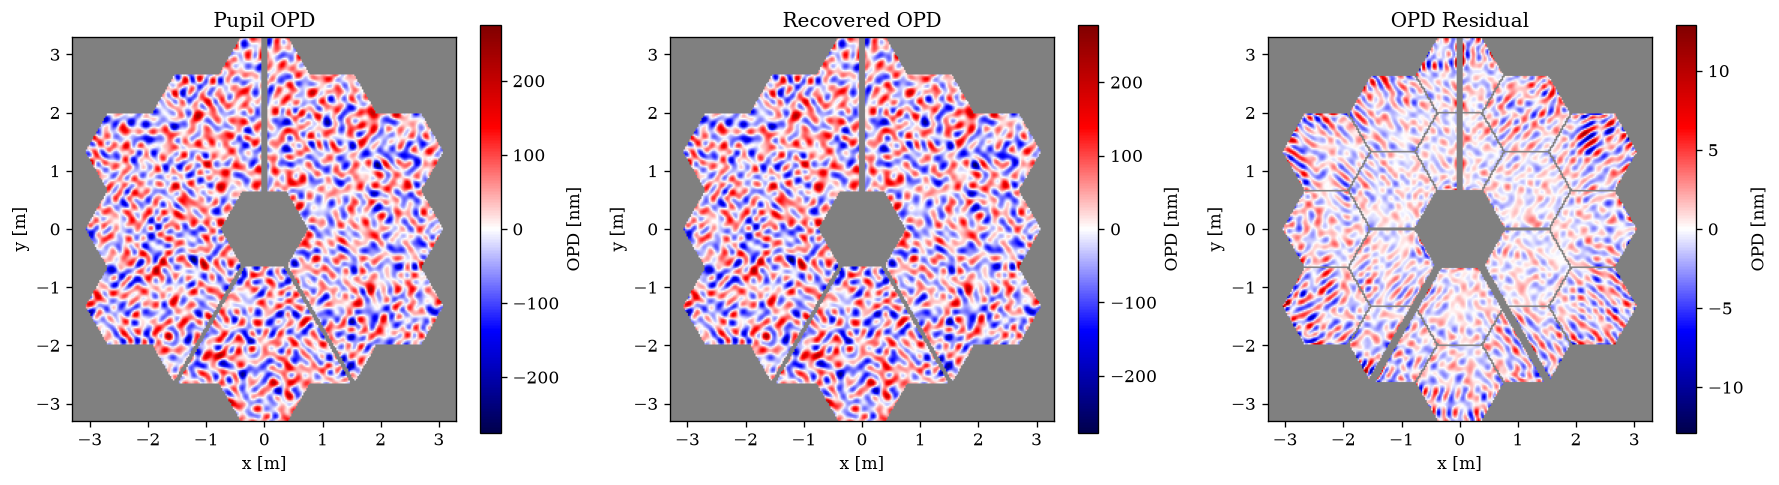

In [8]:
## COLLAPSE: Plotting code
true_opd = optics.pupil.opd.evaluate()
recovered_opd = optics.set("pupil.opd.coeffs", 1e-9 * sol.value["coeffs"]).pupil.opd.evaluate()
residual_opd = recovered_opd - true_opd

true_pupil = 1e9 * true_opd.at[aper <= 0].set(np.nan)
recovered_pupil = 1e9 * recovered_opd.at[aper <= 0].set(np.nan)
residual_pupil = 1e9 * residual_opd.at[aper < 1.].set(np.nan)
residual_pupil -= np.nanmean(residual_pupil)

plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
plt.imshow(true_pupil, seismic, norm=CenteredNorm(), extent=ap_ext)
plt.colorbar(label="OPD [nm]")
ax.set(xlabel="x [m]", ylabel="y [m]", title="Pupil OPD")

ax = plt.subplot(1, 3, 2)
plt.imshow(recovered_pupil, seismic, norm=CenteredNorm(), extent=ap_ext)
plt.colorbar(label="OPD [nm]")
ax.set(xlabel="x [m]", ylabel="y [m]", title="Recovered OPD")

ax = plt.subplot(1, 3, 3)
plt.imshow(residual_pupil, seismic, norm=CenteredNorm(), extent=ap_ext)
plt.colorbar(label="OPD [nm]")
ax.set(xlabel="x [m]", ylabel="y [m]", title="OPD Residual")

plt.tight_layout()
plt.show()

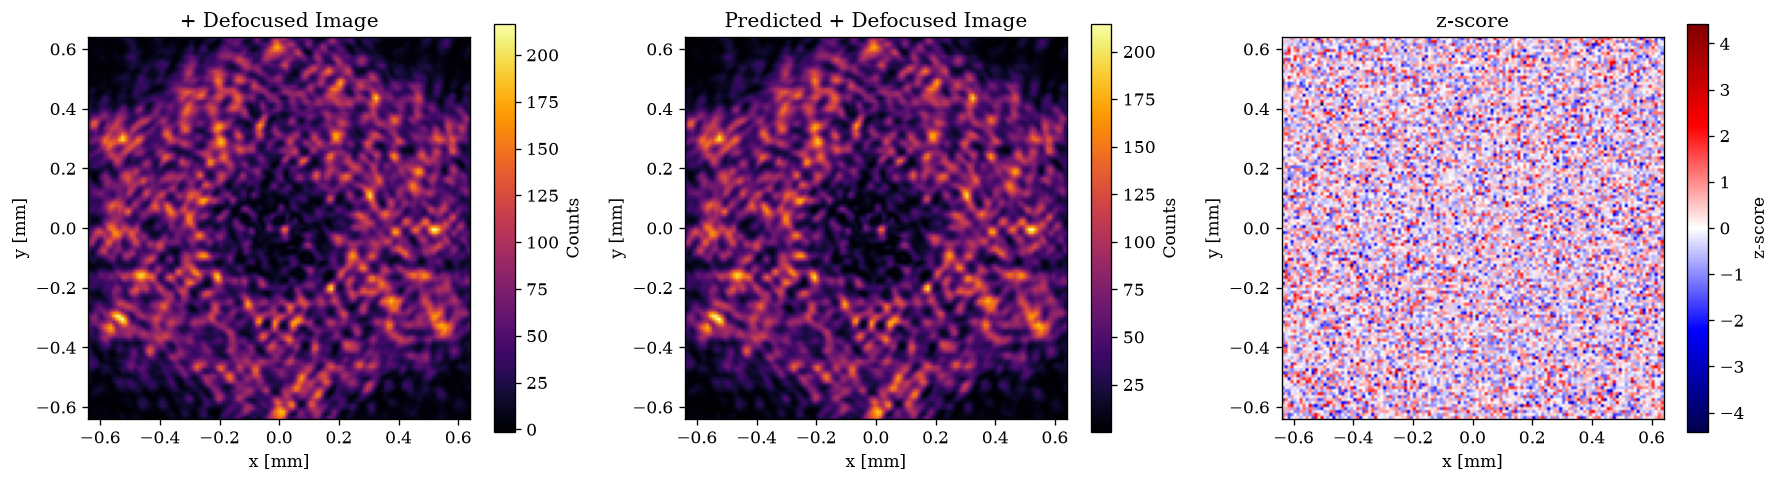

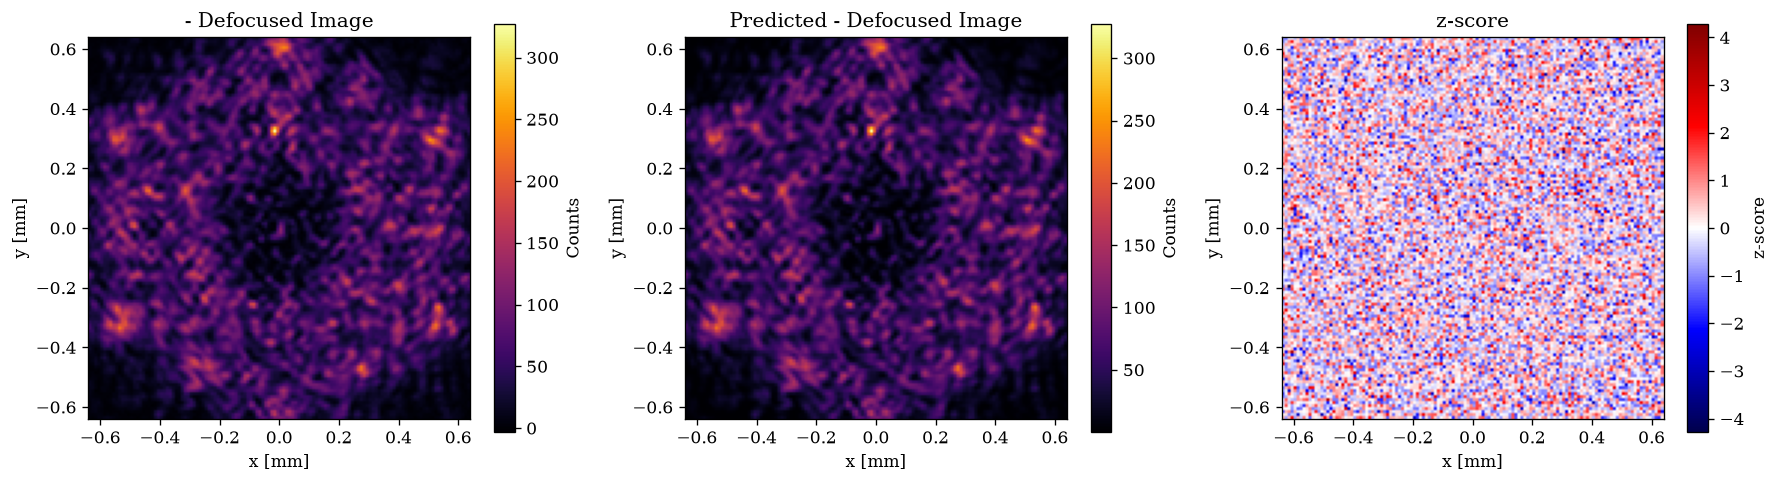

In [9]:
## COLLAPSE: Plotting code
pred = eval_wfs_data(sol.value, optics)
zs = z_score_fn(sol.value, optics, data, error)

plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
# plt.title("+Defocus Image")
plt.imshow(data[0], inferno, extent=psf_ext)
plt.colorbar(label="Counts")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="+ Defocused Image")

ax = plt.subplot(1, 3, 2)
# plt.title("Predicted +Defocus Image")
plt.imshow(pred[0], inferno, extent=psf_ext)
plt.colorbar(label="Counts")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="Predicted + Defocused Image")

ax = plt.subplot(1, 3, 3)
# plt.title("z-score")
plt.imshow(zs[0], seismic, norm=CenteredNorm(), extent=psf_ext)
plt.colorbar(label="z-score")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="z-score")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
# plt.title("-Defocus Image")
plt.imshow(data[1], inferno, extent=psf_ext)
plt.colorbar(label="Counts")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="- Defocused Image")

ax = plt.subplot(1, 3, 2)
# plt.title("Predicted -Defocus Image")
plt.imshow(pred[1], inferno, extent=psf_ext)
plt.colorbar(label="Counts")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="Predicted - Defocused Image")

ax = plt.subplot(1, 3, 3)
# plt.title("z-score")
plt.imshow(zs[1], seismic, norm=CenteredNorm(), extent=psf_ext)
plt.colorbar(label="z-score")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title="z-score")

plt.tight_layout()
plt.show()